# Copper Price Forecasting

Forecast FRED series **PCOPPUSDM**, the monthly global copper price in USD per metric ton. This workflow compares naive and traditional baselines with a cutoff-aware agentic forecaster inspired by `energy_oil_forecasting`.

Live FRED and model calls are disabled by default. The notebook can be dry-run with synthetic data until credentials are configured.

## 1. Install and import dependencies

Run `uv sync` from the repository root before opening the notebook. The implementation uses the repository's forecasting package, Prophet, statsmodels, and Plotly.

In [1]:
import json
import os
import random
import sys
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import yaml
from dotenv import load_dotenv
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf


ROOT = next(
    path
    for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "pyproject.toml").exists() and (path / "aieng-forecasting").exists()
)
sys.path.insert(0, str(ROOT / "implementations"))
load_dotenv(ROOT / ".env", override=False)
random.seed(42)
np.random.seed(42)

from aieng.forecasting.evaluation import MultiTargetBacktestSpec, cached_multi_backtest, describe_spec
from aieng.forecasting.methods.baselines import LastValuePredictor
from copper_forecasting.agent import build_copper_agent_predictor, build_copper_basic_config, build_copper_news_config
from copper_forecasting.data import COPPER_FRED_ID, COPPER_SERIES_ID, build_copper_service, naive_utc_now
from copper_forecasting.prophet_baseline import CopperProphetPredictor

## 2. Configure FRED access and forecast settings

`RUN_DOWNLOAD=False` is the network safety switch. Set it to `True` only after adding `FRED_API_KEY` to the repository-root `.env`. Baseline and agent backtests have independent run guards because the latter makes multiple token-consuming calls.

In [2]:
@dataclass(frozen=True)
class CopperConfig:
    fred_series_id: str = COPPER_FRED_ID
    start: str = "1990-01-01"
    frequency: str = "MS"
    horizons: tuple[int, ...] = (1, 3, 6)
    confidence: float = 0.80
    rolling_window: int = 12
    cache_dir: Path = ROOT / "data" / "fred"
    api_key_env: str = "FRED_API_KEY"


CONFIG = CopperConfig()
RUN_DOWNLOAD = False
USE_SYNTHETIC_IF_CACHE_MISSING = True
RUN_BASELINE_BACKTESTS = True
RUN_AGENT_BACKTEST = False
AGENT_MODEL = "gemini-3.1-flash-lite-preview"
# AGENT_MODEL = "gemini-3.5-flash"  # advanced

print(CONFIG)
print("Live FRED download enabled:", RUN_DOWNLOAD)
print("Baseline backtests enabled:", RUN_BASELINE_BACKTESTS)
print("Agent backtest enabled:", RUN_AGENT_BACKTEST)

CopperConfig(fred_series_id='PCOPPUSDM', start='1990-01-01', frequency='MS', horizons=(1, 3, 6), confidence=0.8, rolling_window=12, cache_dir=PosixPath('/home/coder/agentic-forecasting/data/fred'), api_key_env='FRED_API_KEY')
Live FRED download enabled: False
Baseline backtests enabled: True
Agent backtest enabled: False


## 3. Fetch or load cached copper prices

The repository adapter caches FRED data at `data/fred/PCOPPUSDM.parquet`. With downloading disabled, this cell reads that file if present. Otherwise it generates a labeled synthetic development series so the remaining pipeline can be exercised without network access.

In [3]:
cache_path = CONFIG.cache_dir / f"{CONFIG.fred_series_id}.parquet"

if RUN_DOWNLOAD:
    if not os.environ.get(CONFIG.api_key_env):
        raise RuntimeError(f"Set {CONFIG.api_key_env} in {ROOT / '.env'} before enabling RUN_DOWNLOAD.")
    data_service = build_copper_service(CONFIG.cache_dir, refresh=True)
    history = data_service.get_series(COPPER_SERIES_ID, as_of=naive_utc_now())
    data_source = "FRED API"
elif cache_path.exists():
    data_service = build_copper_service(CONFIG.cache_dir)
    history = data_service.get_series(COPPER_SERIES_ID, as_of=naive_utc_now())
    data_source = f"FRED cache: {cache_path}"
elif USE_SYNTHETIC_IF_CACHE_MISSING:
    dates = pd.date_range("1990-01-01", periods=420, freq=CONFIG.frequency)
    innovations = np.random.normal(0, 0.035, len(dates))
    values = 2600 * np.exp(np.cumsum(0.002 + innovations))
    history = pd.DataFrame({"timestamp": dates, "value": values, "released_at": dates})
    data_service = None
    data_source = "SYNTHETIC DEVELOPMENT DATA - NOT FRED"
else:
    history = None
    data_service = None
    data_source = "unavailable"

print(data_source)
if history is None:
    print(f"Add FRED_API_KEY to {ROOT / '.env'}, set RUN_DOWNLOAD=True, and rerun this cell.")
else:
    print(f"Loaded {len(history):,} monthly observations.")

FRED cache: /home/coder/agentic-forecasting/data/fred/PCOPPUSDM.parquet
Loaded 415 monthly observations.


## 4. Validate and prepare the time series

Dates and values are normalized, duplicates are removed, and the series is reindexed monthly. Missing values are forward-filled using only prior observations. Log prices, returns, and differences are then derived from that cleaned level series.

In [4]:
if history is not None:
    copper = history.loc[:, ["timestamp", "value"]].copy()
    copper["timestamp"] = pd.to_datetime(copper["timestamp"])
    copper["value"] = pd.to_numeric(copper["value"], errors="coerce")
    copper = copper.dropna().drop_duplicates("timestamp", keep="last").sort_values("timestamp")
    copper = copper.set_index("timestamp").asfreq(CONFIG.frequency)
    missing_months = int(copper["value"].isna().sum())
    copper["price"] = copper["value"].ffill()
    copper["log_price"] = np.log(copper["price"])
    copper["return"] = copper["log_price"].diff()
    copper["difference"] = copper["price"].diff()
    assert copper["price"].notna().all(), "Leading missing values require an explicit policy."
    print(f"Missing monthly periods filled from prior values: {missing_months}")
    display(copper.tail())

Missing monthly periods filled from prior values: 0


,value,price,log_price,return,difference
timestamp,,,,,
2026-03-01,12528.709545,12528.709545,9.435778,-0.033177,-422.635455
2026-04-01,12890.687727,12890.687727,9.464260,0.028482,361.978182
2026-05-01,13512.156190,13512.156190,9.511345,0.047085,621.468463
2026-06-01,13552.040909,13552.040909,9.514292,0.002947,39.884719
2026-07-01,13542.820870,13542.820870,9.513612,-0.000681,-9.220040


## 5. Explore copper price dynamics

Inspect levels, returns, rolling volatility, seasonality, autocorrelation, and stationarity before choosing model assumptions.

,price,return,rolling_mean_12m,rolling_vol_12m
timestamp,,,,
2025-02-01,9330.975000,0.038709,9279.715343,0.046346
2025-03-01,9735.823333,0.042473,9366.632367,0.046131
2025-04-01,9172.695909,-0.059581,9343.890889,0.043755
2025-05-01,9531.200909,0.038339,9295.060675,0.039985
2025-06-01,9835.068095,0.031384,9310.635767,0.038829
2025-07-01,9770.580435,-0.006579,9342.741382,0.037852
2025-08-01,9671.875714,-0.010154,9400.304548,0.035166
2025-09-01,9994.773182,0.032840,9461.608266,0.035321
2025-10-01,10739.918261,0.071905,9562.102179,0.039706


,mean_log_return
month,
1,0.011905
2,0.011987
3,0.015273
4,0.011379
5,0.004034
6,-0.006276
7,0.009601
8,-0.004463
9,-0.000205


ADF p-value (log price): 0.7488365127113918
KPSS p-value (log price): 0.01


/tmp/ipykernel_6441/4276396246.py:30: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print("KPSS p-value (log price):", kpss(copper["log_price"].dropna(), regression="ct", nlags="auto")[1])


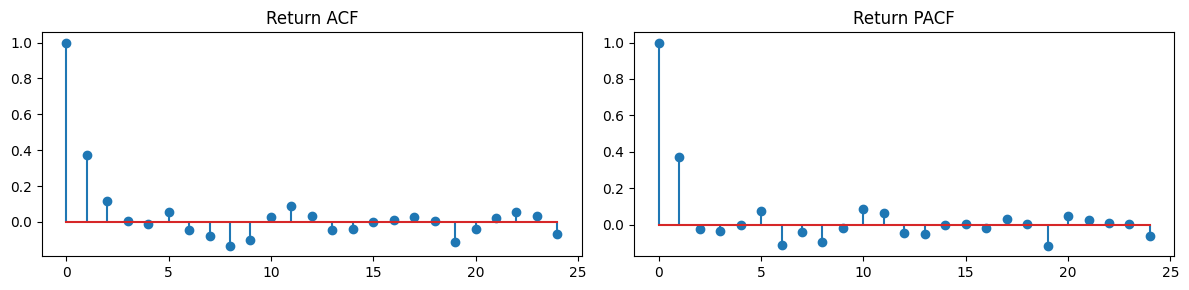

In [5]:
if history is not None:
    import matplotlib.pyplot as plt

    plot_frame = copper.reset_index()
    px.line(
        plot_frame,
        x="timestamp",
        y="price",
        title=f"Monthly copper price ({data_source})",
        labels={"price": "USD per metric ton"},
    ).show()

    diagnostics = copper[["price", "return"]].copy()
    diagnostics["rolling_mean_12m"] = diagnostics["price"].rolling(CONFIG.rolling_window).mean()
    diagnostics["rolling_vol_12m"] = diagnostics["return"].rolling(CONFIG.rolling_window).std()
    display(diagnostics.tail(18))

    seasonal = copper.assign(month=copper.index.month).groupby("month")["return"].mean()
    display(seasonal.rename("mean_log_return").to_frame())

    returns = copper["return"].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].stem(range(25), acf(returns, nlags=24))
    axes[0].set_title("Return ACF")
    axes[1].stem(range(25), pacf(returns, nlags=24, method="ywm"))
    axes[1].set_title("Return PACF")
    plt.tight_layout()

    print("ADF p-value (log price):", adfuller(copper["log_price"].dropna())[1])
    print("KPSS p-value (log price):", kpss(copper["log_price"].dropna(), regression="ct", nlags="auto")[1])

## 6. Create leakage-safe backtesting splits

Each origin exposes only observations at or before that month. The YAML spec uses quarterly origins, 60 months of warmup, and 1, 3, and 6-month horizons.

In [6]:
spec_path = ROOT / "implementations" / "copper_forecasting" / "specs" / "copper_backtest.yaml"
backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(spec_path.read_text()))
task = backtest_spec.tasks[0]

if data_service is not None:
    print(describe_spec(backtest_spec, data_service))
else:
    print(backtest_spec)


def expanding_splits(series: pd.Series, *, min_train: int, horizon: int, stride: int = 1):
    """Yield train/test positions; no future row enters a training slice."""
    for stop in range(min_train, len(series) - horizon + 1, stride):
        yield np.arange(stop), np.arange(stop, stop + horizon)


split_preview = list(expanding_splits(copper["price"], min_train=60, horizon=max(CONFIG.horizons), stride=3))
print("Expanding-window splits available:", len(split_preview))

MultiTargetBacktestSpec (spec_id=copper_monthly_backtest)
  description: Quarterly-origin backtest over 2018-2024 for FRED's monthly global copper price. Compares 1, 3, and 6-month probabilistic forecasts using CRPS.
  start:       2018-01-01 00:00:00
  end:         2024-12-01 00:00:00
  stride:      3
  warmup:      60
  tasks:       1

Task: copper_price_forecast
  description: Global monthly copper price in USD per metric ton from FRED PCOPPUSDM, projected 1, 3, and 6 months ahead.
  horizons:    [1, 3, 6] (len=3)
  frequency:   MS
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: global_copper_price_usd_per_metric_ton
    description:    Global price of copper from FRED series PCOPPUSDM
    source:         FRED (IMF primary commodity prices)
    units:          USD per metric ton
    frequency:      MS

Expanding-window splits available: 117


## 7. Implement naive baselines

These transparent functions make the assumptions visible: persistence, historical mean, drift, 12-month seasonal repetition, and a trailing moving average. The repository's `LastValuePredictor` remains the canonical naive comparator in scored backtests.

In [7]:
def naive_forecast(train: pd.Series, horizon: int, method: str, window: int = 12) -> np.ndarray:
    if method == "last_value":
        return np.repeat(train.iloc[-1], horizon)
    if method == "historical_mean":
        return np.repeat(train.mean(), horizon)
    if method == "drift":
        slope = (train.iloc[-1] - train.iloc[0]) / max(len(train) - 1, 1)
        return train.iloc[-1] + slope * np.arange(1, horizon + 1)
    if method == "seasonal_naive":
        if len(train) < 12:
            return np.repeat(train.iloc[-1], horizon)
        return np.resize(train.iloc[-12:].to_numpy(), horizon)
    if method == "moving_average":
        return np.repeat(train.iloc[-window:].mean(), horizon)
    raise ValueError(f"Unknown naive method: {method}")


baseline_preview = pd.DataFrame(
    {
        method: naive_forecast(copper["price"], max(CONFIG.horizons), method)
        for method in ("last_value", "historical_mean", "drift", "seasonal_naive", "moving_average")
    },
    index=pd.date_range(copper.index[-1] + pd.offsets.MonthBegin(1), periods=max(CONFIG.horizons), freq="MS"),
)
display(baseline_preview)

,last_value,historical_mean,drift,seasonal_naive,moving_average
2026-08-01,13542.82087,5310.802881,13570.338360,9671.875714,12081.160526
2026-09-01,13542.82087,5310.802881,13597.855851,9994.773182,12081.160526
2026-10-01,13542.82087,5310.802881,13625.373342,10739.918261,12081.160526
2026-11-01,13542.82087,5310.802881,13652.890833,10812.028000,12081.160526
2026-12-01,13542.82087,5310.802881,13680.408324,11790.964091,12081.160526
2027-01-01,13542.82087,5310.802881,13707.925815,12986.606818,12081.160526


## 8. Implement traditional statistical models

Exponential smoothing, damped Holt trend, AutoReg, and the reusable Prophet predictor provide conventional alternatives. Fit failures fall back to persistence and are recorded instead of silently stopping the experiment.

In [8]:
from statsmodels.tsa.ar_model import AutoReg


def traditional_forecast(train: pd.Series, horizon: int, method: str) -> tuple[np.ndarray, str | None]:
    try:
        if method == "ets":
            fitted = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
        elif method == "holt_damped":
            fitted = Holt(train, damped_trend=True).fit()
        elif method == "autoreg":
            fitted = AutoReg(train, lags=min(12, len(train) // 4), old_names=False, trend="ct").fit()
        else:
            raise ValueError(f"Unknown traditional method: {method}")
        return np.asarray(fitted.forecast(horizon), dtype=float), None
    except (ValueError, np.linalg.LinAlgError) as exc:
        return naive_forecast(train, horizon, "last_value"), f"fallback after {type(exc).__name__}: {exc}"


traditional_preview = {}
fit_notes = {}
for method in ("ets", "holt_damped", "autoreg"):
    traditional_preview[method], fit_notes[method] = traditional_forecast(copper["price"], max(CONFIG.horizons), method)
display(pd.DataFrame(traditional_preview, index=baseline_preview.index))
print({name: note for name, note in fit_notes.items() if note})

,ets,holt_damped,autoreg
2026-08-01,13534.184562,13612.903395,13499.945461
2026-09-01,13596.746684,13668.969414,13446.431008
2026-10-01,13570.352556,13713.822229,13451.214657
2026-11-01,13525.782831,13749.704481,13621.870085
2026-12-01,13548.904468,13778.410283,13745.033510
2027-01-01,13624.780979,13801.374924,13568.089940


{}


## 9. Build the agentic forecasting components

The packaged agent uses validated `ContinuousAgentForecastOutput`, so its point and quantile forecasts must satisfy the same schema as every other predictor. The basic configuration sees only cutoff-safe history; the news configuration adds independently verified, cutoff-aware search about supply, inventories, demand, currencies, and market outlooks.

In [9]:
basic_config = build_copper_basic_config(model=AGENT_MODEL)
news_config = build_copper_news_config(model=AGENT_MODEL)
agent_predictor = build_copper_agent_predictor(news_config)

agent_components = pd.DataFrame(
    [
        {"component": "data quality", "evidence": "monthly validation and missing-period report"},
        {"component": "regime diagnostics", "evidence": "returns, rolling volatility, ACF/PACF, ADF/KPSS"},
        {"component": "candidate models", "evidence": "naive family, ETS, Holt, AutoReg, Prophet"},
        {"component": "context retrieval", "evidence": "cutoff-aware, independently verified search"},
        {"component": "risk contract", "evidence": "validated quantiles plus rationale"},
    ]
)
display(agent_components)
print("History-only agent:", basic_config.name)
print("News-grounded agent:", news_config.name)
print("Search enabled:", news_config.context_retrieval.enabled)

,component,evidence
0,data quality,monthly validation and missing-period report
1,regime diagnostics,"returns, rolling volatility, ACF/PACF, ADF/KPSS"
2,candidate models,"naive family, ETS, Holt, AutoReg, Prophet"
3,context retrieval,"cutoff-aware, independently verified search"
4,risk contract,validated quantiles plus rationale


History-only agent: copper_analyst_basic
News-grounded agent: copper_analyst_news
Search enabled: True


## 10. Orchestrate agentic model selection and ensembling

The orchestrator runs each enabled predictor on the same specification, rejects failed candidates, and derives constrained inverse-CRPS weights. Agent calls remain separately gated because a full historical agent backtest can be costly.

In [10]:
from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.features import StaticFrameAdapter
from aieng.forecasting.evaluation import multi_backtest


if data_service is None:
    experiment_service = DataService()
    experiment_service.register(
        COPPER_SERIES_ID,
        StaticFrameAdapter(history[["timestamp", "value", "released_at"]]),
        SeriesMetadata(
            series_id=COPPER_SERIES_ID,
            description="Synthetic copper development series",
            source="synthetic",
            units="USD per metric ton",
            frequency="MS",
        ),
    )
else:
    experiment_service = data_service

predictors = {
    "Naive (last value)": LastValuePredictor(),
    "Prophet": CopperProphetPredictor(interval_width=CONFIG.confidence),
}
results_by_model = {}
decision_log = []

if RUN_BASELINE_BACKTESTS:
    for name, predictor in predictors.items():
        runner = multi_backtest if data_source.startswith("SYNTHETIC") else cached_multi_backtest
        try:
            results_by_model[name] = runner(predictor, backtest_spec, experiment_service)
            score = next(iter(results_by_model[name].values())).mean_score
            decision_log.append({"model": name, "decision": "eligible", "mean_crps": score})
        except (RuntimeError, ValueError) as exc:
            decision_log.append({"model": name, "decision": "rejected", "reason": str(exc)})

if RUN_AGENT_BACKTEST:
    results_by_model["News agent"] = cached_multi_backtest(agent_predictor, backtest_spec, experiment_service)
    score = next(iter(results_by_model["News agent"].values())).mean_score
    decision_log.append({"model": "News agent", "decision": "eligible", "mean_crps": score})

eligible = [row for row in decision_log if row["decision"] == "eligible"]
if eligible:
    inverse_scores = np.array([1 / max(row["mean_crps"], 1e-9) for row in eligible])
    weights = inverse_scores / inverse_scores.sum()
    for row, weight in zip(eligible, weights, strict=True):
        row["ensemble_weight"] = float(weight)

display(pd.DataFrame(decision_log))

,model,decision,mean_crps,ensemble_weight
0,Naive (last value),eligible,585.168152,0.638819
1,Prophet,eligible,1034.983742,0.361181


## 11. Evaluate and compare forecasts

The scorecard reports CRPS from the repository harness plus point and interval diagnostics computed from the same predictions. Lower CRPS, MAE, RMSE, sMAPE, and MASE are better; higher directional accuracy and interval coverage are better.

In [11]:
metric_rows = []
scale = copper.loc[: pd.Timestamp(backtest_spec.start), "price"].diff().abs().mean()

for model_name, result_map in results_by_model.items():
    result = next(iter(result_map.values()))
    records = []
    for prediction, crps_score in zip(result.predictions, result.scores, strict=True):
        forecast_date = pd.Timestamp(prediction.forecast_date)
        as_of = pd.Timestamp(prediction.as_of)
        actual = float(copper.loc[forecast_date, "price"])
        origin = float(copper.loc[:as_of, "price"].iloc[-1])
        point = float(prediction.payload.point_forecast)
        records.append(
            {
                "actual": actual,
                "origin": origin,
                "point": point,
                "crps": crps_score,
                "covered_80": prediction.payload.quantiles[0.10] <= actual <= prediction.payload.quantiles[0.90],
            }
        )
    frame = pd.DataFrame(records)
    errors = frame["point"] - frame["actual"]
    metric_rows.append(
        {
            "Model": model_name,
            "CRPS": frame["crps"].mean(),
            "MAE": errors.abs().mean(),
            "RMSE": np.sqrt(np.mean(errors**2)),
            "sMAPE": np.mean(2 * errors.abs() / (frame["actual"].abs() + frame["point"].abs())) * 100,
            "MASE": errors.abs().mean() / scale,
            "Direction accuracy": (
                np.sign(frame["point"] - frame["origin"]) == np.sign(frame["actual"] - frame["origin"])
            ).mean(),
            "80% coverage": frame["covered_80"].mean(),
            "Scored forecasts": len(frame),
        }
    )

leaderboard = pd.DataFrame(metric_rows).sort_values("CRPS") if metric_rows else pd.DataFrame()
display(leaderboard)

,Model,CRPS,MAE,RMSE,sMAPE,MASE,Direction accuracy,80% coverage,Scored forecasts
0,Naive (last value),585.168152,585.168152,838.343002,7.576913,2.861817,0.000000,0.000000,84
1,Prophet,1034.983742,1323.689260,1743.403978,17.649674,6.473619,0.559524,0.583333,84


## 12. Fit the selected approach and forecast future prices

Refit the reusable predictors at the latest observation, retain conventional forecasts for comparison, and create the weighted ensemble when backtest-derived weights are available. The agent is included only when its run guard is enabled.

In [12]:
as_of = pd.Timestamp(history["timestamp"].max())
context = experiment_service.context(as_of=as_of)
model_predictions = {name: predictor.predict(task, context) for name, predictor in predictors.items()}
if RUN_AGENT_BACKTEST:
    model_predictions["News agent"] = agent_predictor.predict(task, context)

future_rows = []
for model_name, predictions in model_predictions.items():
    for horizon, prediction in zip(task.horizons, predictions, strict=True):
        payload = prediction.payload
        future_rows.append(
            {
                "Model": model_name,
                "Horizon": horizon,
                "Forecast date": prediction.forecast_date,
                "Point": payload.point_forecast,
                "q10": payload.quantiles[0.10],
                "q90": payload.quantiles[0.90],
            }
        )

preview_forecasts = {
    **{name: baseline_preview[name].to_numpy() for name in baseline_preview},
    **traditional_preview,
}
for method, values in preview_forecasts.items():
    for horizon in task.horizons:
        future_rows.append(
            {
                "Model": method,
                "Horizon": horizon,
                "Forecast date": as_of + pd.offsets.MonthBegin(horizon),
                "Point": float(values[horizon - 1]),
                "q10": np.nan,
                "q90": np.nan,
            }
        )

future_forecasts = pd.DataFrame(future_rows)
if eligible:
    weight_by_model = {row["model"]: row["ensemble_weight"] for row in eligible}
    weighted = future_forecasts[future_forecasts["Model"].isin(weight_by_model)].copy()
    weighted["weighted_point"] = weighted.apply(lambda row: row["Point"] * weight_by_model[row["Model"]], axis=1)
    ensemble = weighted.groupby(["Horizon", "Forecast date"], as_index=False)["weighted_point"].sum()
    ensemble["Model"] = "Inverse-CRPS ensemble"
    ensemble = ensemble.rename(columns={"weighted_point": "Point"})
    ensemble[["q10", "q90"]] = np.nan
    future_forecasts = pd.concat([future_forecasts, ensemble[future_forecasts.columns]], ignore_index=True)

display(future_forecasts.sort_values(["Horizon", "Model"]))

14:33:14 - cmdstanpy - INFO - Chain [1] start processing
14:33:14 - cmdstanpy - INFO - Chain [1] done processing


,Model,Horizon,Forecast date,Point,q10,q90
30,Inverse-CRPS ensemble,1,2026-08-01,12518.425255,NaN,NaN
0,Naive (last value),1,2026-08-01,13542.820870,13542.820870,13542.820870
3,Prophet,1,2026-08-01,10706.582280,9758.825281,11654.339279
27,autoreg,1,2026-08-01,13499.945461,NaN,NaN
12,drift,1,2026-08-01,13570.338360,NaN,NaN
21,ets,1,2026-08-01,13534.184562,NaN,NaN
9,historical_mean,1,2026-08-01,5310.802881,NaN,NaN
24,holt_damped,1,2026-08-01,13612.903395,NaN,NaN
6,last_value,1,2026-08-01,13542.820870,NaN,NaN
18,moving_average,1,2026-08-01,12081.160526,NaN,NaN


## 13. Visualize and export results

The final chart keeps history and forecasts on one scale. Exports are disabled by default and, when enabled, write timestamped forecasts, metrics, configuration, and the model decision log under `data/predictions/copper/`.

In [13]:
import plotly.graph_objects as go


fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=copper.index[-60:],
        y=copper["price"].iloc[-60:],
        name="History",
        line={"color": "#8c4f2b", "width": 3},
    )
)
for model_name, frame in future_forecasts.groupby("Model"):
    fig.add_trace(
        go.Scatter(
            x=frame["Forecast date"],
            y=frame["Point"],
            mode="lines+markers",
            name=model_name,
        )
    )
fig.update_layout(
    title=f"Copper price forecasts from {as_of.date()} ({data_source})",
    xaxis_title="Month",
    yaxis_title="USD per metric ton",
    template="plotly_white",
)
fig.show()

EXPORT_RESULTS = False
if EXPORT_RESULTS:
    timestamp = datetime.now(tz=timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    export_dir = ROOT / "data" / "predictions" / "copper"
    export_dir.mkdir(parents=True, exist_ok=True)
    future_forecasts.to_csv(export_dir / f"forecasts_{timestamp}.csv", index=False)
    leaderboard.to_csv(export_dir / f"metrics_{timestamp}.csv", index=False)
    (export_dir / f"config_{timestamp}.json").write_text(json.dumps(asdict(CONFIG), default=str, indent=2))
    (export_dir / f"decisions_{timestamp}.json").write_text(json.dumps(decision_log, indent=2))
    print("Exported results to", export_dir)
else:
    print("Set EXPORT_RESULTS=True to write forecast artifacts.")

Set EXPORT_RESULTS=True to write forecast artifacts.
